# NLP with RNN, LSTM, and GRU
## From Raw Text to Sentiment Predictions — A Step-by-Step Guide


---

- Why text must be **cleaned, tokenized, encoded, and padded** before a neural network can use it
- What makes **RNN, LSTM, and GRU** different from each other — and when each is useful
- How to **train and compare** three models fairly using the same data and pipeline
- How to **interpret results**: training curves, confusion matrices, precision, recall, and F1 scores

---


### About the dataset
We use a small, intentionally simple sentiment dataset with short review sentences. The goal is **clarity**, not competition scores. A small dataset means you can read every example yourself and understand exactly what the model is learning from.


Here is the full pipeline we will build, step by step. Think of it as an assembly line: raw text goes in, a prediction comes out, and each stage transforms the data into something more useful.

1. **Load a small sentiment dataset** — See what the raw data looks like before doing anything to it.
2. **Inspect the data** — Check if classes are balanced and how long sentences are. *This prevents surprises later.*
3. **Clean the text** — Lowercase everything, remove punctuation, collapse extra spaces. *Computers are case-sensitive and punctuation adds noise.*
4. **Split into train / validation / test** — Do this *before* building the vocabulary to avoid a subtle but important mistake called data leakage.
5. **Build a vocabulary** — Map every unique word to an integer ID. *Neural networks speak numbers, not words.*
6. **Pad sequences** — Make every sequence the same length. *Batches need to be rectangular, like a matrix.*
7. **Train three models** — RNN, LSTM, and GRU on the exact same task and with the exact same pipeline.
8. **Compare performance** — Accuracy, F1 scores, confusion matrices, and training curves side by side.
9. **Test on custom sentences** — The most intuitive check: give the trained models sentences they have never seen.

---

> **One mental model to hold onto throughout:**
>
> `Text → Clean → Numbers → Padded Matrix → Neural Network → Prediction`
>
> Every section of this notebook is just one step in that chain.

## The Big Picture: NLP Preprocessing Pipeline

Before writing any code, let us trace what happens to a single sentence from start to finish.

**Raw text:**
`"Overall, the game felt GREAT for daily use!"`

**Step 1 — Clean** *(lowercase, remove punctuation)*
`"overall the game felt great for daily use"`

**Step 2 — Tokenize** *(split into individual words)*
`["overall", "the", "game", "felt", "great", "for", "daily", "use"]`

**Step 3 — Encode** *(replace each word with its vocabulary ID)*
`[6, 2, 34, 9, 15, 4, 13, 12]`

**Step 4 — Pad** *(add zeros at the end to reach a fixed length)*
`[6, 2, 34, 9, 15, 4, 13, 12, 0, 0, 0]`  ← the `0` at the end is the padding token

**Step 5 — Feed to the model** → predicts `"positive"`

---

**Why do we need all these steps?**
Neural networks are fundamentally math operations on numbers. They cannot read letters or words directly. Every preprocessing step is a *translation* that brings text closer to the format the model needs.

The diagram below shows this same pipeline visually — study it carefully before moving to the code.

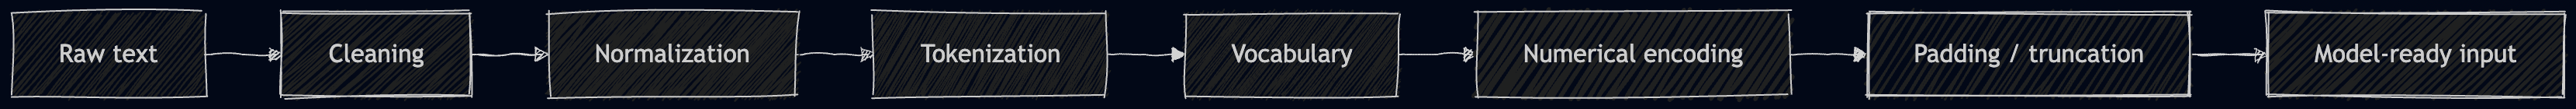

In [ ]:

# - Displays the preprocessing image stored next to this notebook.

# - The pipeline is easier to follow when seen visually before coding.
# Note:
# - The image will be embedded into the executed notebook output.

from IPython.display import Image, display
\
display(Image(filename="nlp_data_preprocessing.png", width=950))

## 1. Imports and Reproducibility Setup

Before we do anything else, we import the libraries we need and fix the random seeds.

**Libraries used in this notebook and what they do:**

| Library | What it does |
|---------|-------------|
| `random`, `re`, `numpy` | Basic Python utilities — random numbers, text patterns, arrays |
| `pandas` | Tabular data (like a spreadsheet in Python) — great for loading and inspecting datasets |
| `matplotlib` + `seaborn` | Plotting libraries for visualizing data and results |
| `sklearn` | Machine learning utilities: train/test splits, and metrics like precision, recall, F1 |
| `torch` (PyTorch) | The deep learning framework we use to build and train our models |
| `collections.Counter` | Counts how many times each word appears — used when building the vocabulary |

**What are random seeds?**
Many operations in deep learning involve randomness — for example, how weights are initialized, or the order data is shuffled. By setting `RANDOM_SEED = 42` and passing it to Python, NumPy, and PyTorch, we make our results *reproducible*. Running this notebook twice should give you the same numbers.

> **What to look for in the output:**
> - `Using device: cuda` — great, training uses a GPU and will be fast.
> - `Using device: cpu` — also fine! This small dataset trains quickly on a CPU too.

In [ ]:

# - Imports all libraries used in the notebook.
# - Sets seeds so results are reproducible.
# - Detects whether a GPU is available.

# - Shows the minimum toolkit needed for an end-to-end NLP notebook.
# Note:
# - We use only standard scientific Python libraries plus PyTorch.

import random
import re
import warnings
from collections import Counter
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)

NOTEBOOK_DIR = Path.cwd()
DATASET_PATH = NOTEBOOK_DIR / "classroom_sentiment_dataset.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Dataset path: {DATASET_PATH}")

Using device: cuda
Dataset path: /content/classroom_sentiment_dataset.csv


## 2. Load the Dataset

Our dataset contains short product and service review sentences. Each row has two pieces of information:

- `text` — the raw review (e.g., *"The app was slow, buggy, AND confusing for daily use."*)
- `label` — the sentiment: either `"positive"` or `"negative"`

**Why do we look at the raw data before doing anything else?**
This is a core habit in data science. Surprises in the raw data — wrong labels, unexpectedly long sentences, strange characters — are much easier to catch and fix early. Never assume the data looks the way you expect.

**What `.head()` and `.sample()` do:**
- `.head()` shows the first 5 rows — but the first rows might not be representative.
- `.sample(6, ...)` shows 6 randomly chosen rows — a more honest preview of what the data actually contains.

> Always look at both. The first rows might accidentally all be from one class or one writing style.

In [ ]:

# - Loads the CSV file into a pandas DataFrame.
# - Shows the first rows and a random sample.

# - Always inspect the raw data before cleaning or modeling.
# Note:
# - Looking at raw examples helps explain why we later lowercase and remove punctuation.

df = pd.read_csv(DATASET_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nRandom examples:")
display(df.sample(6, random_state=RANDOM_SEED).reset_index(drop=True))

Dataset shape: (144, 2)


,text,label
0,"overall, the game felt clear and simple for da...",positive
1,the app was not useful AND kept crashing all day!,negative
2,"the service was weak, unstable, AND unreliable...",negative
3,"Overall, the tablet looked clear and simple fr...",positive
4,"The app was slow, buggy, AND confusing for dai...",negative



Random examples:


,text,label
0,"overall, the game looked messy and unclear for...",negative
1,"overall, the platform seemed pleasant and effi...",positive
2,"The course was engaging, practical, AND enjoya...",positive
3,"the laptop felt weak, unstable, and unreliable...",negative
4,The lesson was not unclear and stayed simple a...,positive
5,"the website looked weak, unstable, and unrelia...",negative


## 3. Quick Data Inspection: Class Balance and Sentence Length

Two fast checks we always do before building a model:

**Check 1 — Class balance**

Are there roughly equal numbers of positive and negative examples?

If one class has 90% of the data and the other has only 10%, a model can "cheat" by always predicting the majority class and still achieve 90% accuracy. That is completely useless. Our dataset is intentionally balanced (50/50), which keeps the lesson fair and the metrics meaningful.

**Check 2 — Sentence length**

How many words are in each sentence?

Very long sequences (hundreds of words) make training slower and the vanishing gradient problem worse. Our sentences are short — around 8 to 11 words — which is ideal for this notebook. It also means RNN should still work reasonably well even without gated memory.

---

> **What to look for in the output:**
> - The bar chart should show roughly **equal heights** for positive and negative.
> - The histogram should show a **tight, narrow distribution** — most sentences have a similar length.
> - The summary table below the chart shows the **min, average, and max** number of words per sentence.

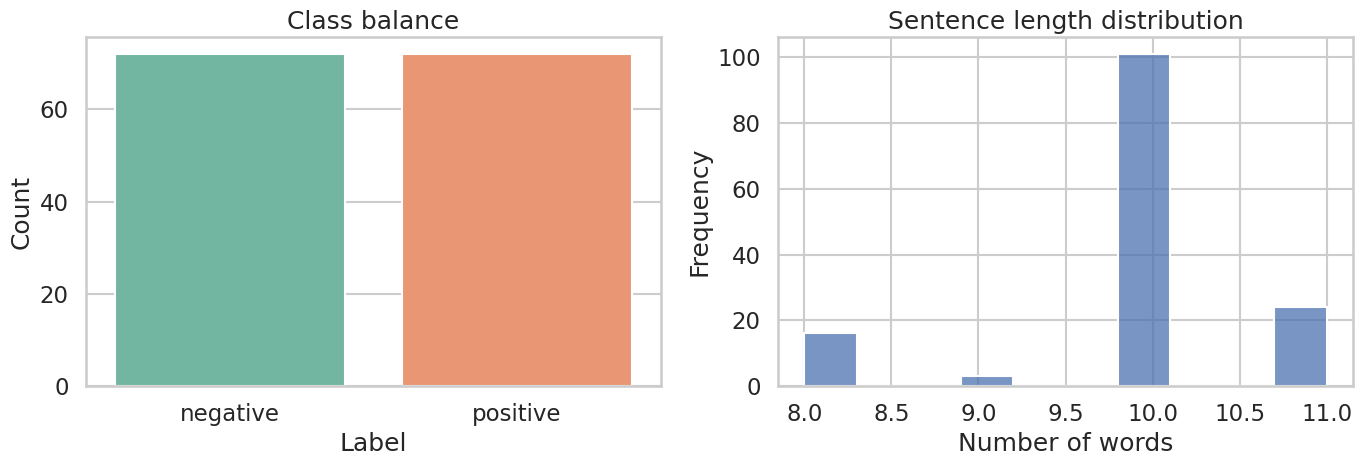

,metric,value
0,minimum length,8.00
1,average length,9.92
2,maximum length,11.00


In [ ]:

# - Counts the labels.
# - Measures sentence length in words.
# - Plots both views side by side.

# - Class imbalance and very long sequences would make the lesson harder to explain.
# Note:
# - Here the dataset is intentionally small and nearly balanced.

df["raw_length"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df["label"].value_counts().sort_index()
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Class balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

sns.histplot(df["raw_length"], bins=10, kde=False, color="#4C72B0", ax=axes[1])
axes[1].set_title("Sentence length distribution")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric": ["minimum length", "average length", "maximum length"],
            "value": [
                int(df["raw_length"].min()),
                round(df["raw_length"].mean(), 2),
                int(df["raw_length"].max()),
            ],
        }
    )
)

## 4. Clean the Text

Raw text is messy. Computers are case-sensitive and easily confused by punctuation. We apply three simple normalization rules:

**Rule 1 — Lowercase everything**
`"GREAT"` and `"great"` are the same word to a human, but a computer sees them as completely different strings. Lowercasing makes sure they map to the same vocabulary entry.

**Rule 2 — Remove punctuation and special characters**
Commas, exclamation marks, and words typed in ALL CAPS (like `"AND"`) add noise without changing the core meaning. We keep only letters, numbers, and spaces.

**Rule 3 — Collapse extra spaces**
After removing characters, gaps may appear. For example, `"hello , world"` becomes `"hello  world"` (double space). We tidy that up.

---

**One important exception — we intentionally keep the word "not"**

This is a crucial NLP design decision. Consider these two sentences:
- `"The game was enjoyable"` → positive
- `"The game was not enjoyable"` → negative

The word `"not"` flips the entire meaning. If we blindly removed common words (called *stopwords*), we would lose this negation signal and the model would be badly confused. We keep `"not"` and other negation words explicitly.

---

> **What to look for in the output:**
> Compare the `text` column to the new `clean_text` column. Uppercase letters, commas, and exclamation marks should all be gone, while the core words remain intact.

In [ ]:

# - Defines a simple cleaning function.
# - Applies it to the full dataset.
# - Shows before/after examples.

# - Cleaning reduces vocabulary noise while keeping the lesson transparent.
# Note:
# - We keep the word "not" because it changes sentiment meaning.

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)

preview = df.loc[:7, ["text", "clean_text"]].copy()
display(preview)

,text,clean_text
0,"overall, the game felt clear and simple for da...",overall the game felt clear and simple for dai...
1,the app was not useful AND kept crashing all day!,the app was not useful and kept crashing all day
2,"the service was weak, unstable, AND unreliable...",the service was weak unstable and unreliable f...
3,"Overall, the tablet looked clear and simple fr...",overall the tablet looked clear and simple fro...
4,"The app was slow, buggy, AND confusing for dai...",the app was slow buggy and confusing for daily...
5,the game was not enjoyable AND turned annoying.,the game was not enjoyable and turned annoying
6,"Overall, the laptop seemed messy and unclear f...",overall the laptop seemed messy and unclear fo...
7,"the app was limited, awkward, AND disappointin...",the app was limited awkward and disappointing ...


## 5. Split the Data Before Building the Vocabulary

This is a small step with a big consequence — and it is a very common mistake to get it wrong.

**Why split first?**

Think of it like an exam. The answers are never revealed beforehand — that would be cheating. The same rule applies to machine learning:

- The **training set** is what the model learns from.
- The **validation set** is used during training to monitor how well the model generalizes — it is never used for learning.
- The **test set** is the final exam — it is used *once*, at the very end, to report honest performance.

**What is data leakage?**

If we built our vocabulary using all the data — including validation and test rows — then information from the "exam" would sneak into the vocabulary. This is called **data leakage**. It subtly inflates performance numbers and gives you a false sense of how good the model is.

The correct approach: build the vocabulary from **training data only**. If the validation or test set contains a word that was never in training, the model will see it as `<UNK>` (unknown). That is the honest behaviour.

**Our split:** 70% train · 15% validation · 15% test, using `stratify` to ensure each split has equal positive and negative examples.

> **What to look for in the output:**
> The table should show roughly **100 training, 22 validation, 22 test** examples with equal class counts in each split.

In [ ]:

# - Creates train, validation, and test splits.
# - Uses stratification so each split keeps the same label balance.

# - A fair comparison needs separate data for training, tuning, and final testing.
# Note:
# - We use a two-step split to get 70% train, 15% validation, and 15% test.

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=RANDOM_SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "positive": [
            int((train_df["label"] == "positive").sum()),
            int((val_df["label"] == "positive").sum()),
            int((test_df["label"] == "positive").sum()),
        ],
        "negative": [
            int((train_df["label"] == "negative").sum()),
            int((val_df["label"] == "negative").sum()),
            int((test_df["label"] == "negative").sum()),
        ],
    }
)

display(split_summary)

,split,rows,positive,negative
0,train,100,50,50
1,validation,22,11,11
2,test,22,11,11


## 6. Build a Vocabulary and Convert Words to Numbers

**The core challenge:** Neural networks work with numbers, not words. We need to create a translation dictionary that maps every unique word to an integer ID.

**Step by step:**

1. **Tokenize** — Split each cleaned sentence into individual words:
   `"the game was great"` → `["the", "game", "was", "great"]`

2. **Count frequencies** — Count how often each word appears *in the training set only*.

3. **Assign IDs** — Sort words by frequency and assign a unique integer to each:
   `"the"` → `2` (most common), `"and"` → `3`, `"great"` → `15`, etc.

4. **Add two reserved tokens:**
   - `<PAD>` (ID = 0) — Used to fill shorter sequences up to the maximum length
   - `<UNK>` (ID = 1) — Used when the model encounters a word it has never seen during training

**A concrete example:**

Sentence: `"the game was not great"`
After encoding: `[2, 34, 8, 5, 15]`
After padding to length 11: `[2, 34, 8, 5, 15, 0, 0, 0, 0, 0, 0]`

**Why PAD (ID = 0)?**
All sentences in a batch must be the same length so they can be stacked into a matrix. We add zeros at the end of shorter sentences to reach a fixed `max_length`. The model is told to ignore these zeros.

**Why UNK (ID = 1)?**
At test time, the model may encounter words it never saw during training (e.g., a brand name). Instead of crashing, we map those words to `<UNK>` — this simulates the real world honestly.

> **What to look for in the output:**
> The vocabulary size printout tells you how many unique words were found in the training data. Also verify that `<PAD>` has ID 0 and `<UNK>` has ID 1.

In [ ]:

# - Tokenizes the cleaned text with a simple split.
# - Builds the vocabulary from training data only.
# - Shows the most common tokens and the vocabulary size.

# - This step shows the bridge from language to numbers.
# Note:
# - Building the vocabulary on training data only avoids leakage.

# Define a simple tokenizer that splits a string on whitespace.
def tokenize(text: str) -> list[str]:
    return text.split()


# Apply tokenization to every split so all data can be mapped to token IDs later.
for split_df in [train_df, val_df, test_df]:
    split_df["tokens"] = split_df["clean_text"].apply(tokenize)

# Count token frequencies using only the training set to prevent data leakage.
token_counter = Counter(
    token for tokens in train_df["tokens"] for token in tokens
)

# Reserve index 0 for padding and index 1 for unknown words, then assign indices by frequency.
word_to_idx = {"<PAD>": 0, "<UNK>": 1}
for token, count in sorted(token_counter.items(), key=lambda item: (-item[1], item[0])):
    word_to_idx[token] = len(word_to_idx)

# Create a reverse lookup dictionary to map integer IDs back to words.
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
PAD_IDX = word_to_idx["<PAD>"]
UNK_IDX = word_to_idx["<UNK>"]

# Report vocabulary size and display the 20 most common tokens.
print(f"Vocabulary size (including PAD and UNK): {len(word_to_idx)}")
display(pd.DataFrame(token_counter.most_common(20), columns=["token", "count"]))

Vocabulary size (including PAD and UNK): 76


,token,count
0,the,117
1,and,100
2,for,55
3,was,35
4,overall,34
5,looked,24
6,seemed,23
7,felt,22
8,most,20
9,tasks,20


In [ ]:

# - Encodes tokens as integers.
# - Pads each sequence to a common maximum length.
# - Converts labels into 0 and 1.

# - PyTorch sequence layers expect numerical tensor inputs.
# Note:
# - We save the true sequence length so the model can ignore padded positions later.

LABEL_TO_ID = {"negative": 0, "positive": 1}
max_length = max(len(tokens) for tokens in train_df["tokens"])


def encode_tokens(tokens: list[str], vocab: dict[str, int]) -> list[int]:
    return [vocab.get(token, UNK_IDX) for token in tokens]


def pad_sequence(encoded_tokens: list[int], max_len: int, pad_idx: int) -> list[int]:
    if len(encoded_tokens) >= max_len:
        return encoded_tokens[:max_len]
    return encoded_tokens + [pad_idx] * (max_len - len(encoded_tokens))


def prepare_split(split_df: pd.DataFrame):
    sequences = []
    lengths = []
    labels = []

    for _, row in split_df.iterrows():
        token_ids = encode_tokens(row["tokens"], word_to_idx)
        effective_length = min(len(token_ids), max_length)
        padded_ids = pad_sequence(token_ids, max_length, PAD_IDX)
        sequences.append(padded_ids)
        lengths.append(effective_length)
        labels.append(LABEL_TO_ID[row["label"]])

    return (
        torch.tensor(sequences, dtype=torch.long),
        torch.tensor(lengths, dtype=torch.long),
        torch.tensor(labels, dtype=torch.float32),
    )


X_train, train_lengths, y_train = prepare_split(train_df)
X_val, val_lengths, y_val = prepare_split(val_df)
X_test, test_lengths, y_test = prepare_split(test_df)

print(f"Max sequence length used for padding: {max_length}")
print(f"Training tensor shape: {tuple(X_train.shape)}")

Max sequence length used for padding: 11
Training tensor shape: (100, 11)


In [ ]:

# - Follows one example through the preprocessing pipeline.

# - The whole pipeline is easier to understand by tracking one sentence step by step.
# Note:
# - This is often the most important demo cell in the notebook.

sample_text = df.loc[0, "text"]
sample_clean = clean_text(sample_text)
sample_tokens = tokenize(sample_clean)
sample_token_ids = encode_tokens(sample_tokens, word_to_idx)
sample_padded = pad_sequence(sample_token_ids, max_length, PAD_IDX)

print("Raw text:")
print(sample_text)
print("\nClean text:")
print(sample_clean)
print("\nTokens:")
print(sample_tokens)
print("\nToken IDs:")
print(sample_token_ids)
print("\nPadded sequence:")
print(sample_padded)

Raw text:
overall, the game felt clear and simple for daily use.

Clean text:
overall the game felt clear and simple for daily use

Tokens:
['overall', 'the', 'game', 'felt', 'clear', 'and', 'simple', 'for', 'daily', 'use']

Token IDs:
[6, 2, 34, 9, 35, 3, 42, 4, 13, 12]

Padded sequence:
[6, 2, 34, 9, 35, 3, 42, 4, 13, 12, 0]


## 7. Create PyTorch DataLoaders

We have our tensors — now we need a way to feed them to the model in small, manageable chunks called **batches**.

**What is a DataLoader?**

A `DataLoader` is a PyTorch utility that wraps a dataset and serves it in batches automatically. Without it, you would have to manually slice tensors and shuffle indices — tedious and error-prone. The DataLoader does all of this in a single line.

**Why batch training?**

Loading all 100 training examples at once and running a single gradient update would work mathematically, but it has two problems:
1. It is memory-intensive — real datasets have millions of examples.
2. The gradient estimate from the full dataset is expensive to compute for each parameter update.

Mini-batch training (e.g., batches of 16) gives us a gradient estimate that is noisier than the full-batch gradient, but this noise actually helps: it can prevent the model from getting stuck in sharp local minima.

**Why shuffle only the training loader?**

- **Training loader (`shuffle=True`)** — We want the model to see examples in a different order every epoch. If it always saw the same sequence, it might memorize the order rather than learning the patterns.
- **Validation and test loaders (`shuffle=False`)** — We never train on these, so the order does not matter. Keeping it fixed makes it easier to trace specific predictions back to specific examples.

**What each batch contains:**

Each batch has three tensors:
1. Padded token ID matrix — shape `(batch_size, max_length)`
2. Sequence lengths — one integer per example, shape `(batch_size,)`
3. Labels — 0 or 1 for each example, shape `(batch_size,)`

The lengths tensor is carried along because we will pass it to `pack_padded_sequence` inside the model — this tells the recurrent layer exactly where each sequence ends so it never processes padding tokens.

> **What to look for in the output:**
> With 100 training examples and batch size 16, you should get **7 batches** (6 full batches of 16 + 1 partial batch of 4). The validation and test sets give 2 batches each (22 examples ÷ 16 ≈ 2 batches).

In [ ]:

# - Wraps tensors into TensorDataset objects.
# - Builds DataLoaders for train, validation, and test.

# - Batching is required for efficient training.
# Note:
# - We shuffle only the training loader because validation and test should stay stable.

BATCH_SIZE = 16

train_dataset = TensorDataset(X_train, train_lengths, y_train)
val_dataset = TensorDataset(X_val, val_lengths, y_val)
test_dataset = TensorDataset(X_test, test_lengths, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 7
Validation batches: 2
Test batches: 2


## 8. High-level sequence modeling architecture

Before we look at the differences between RNN, LSTM, and GRU, it helps to understand the pipeline that *all three share*. The recurrent layer is just one component inside a larger classifier.

**The shared five-stage pipeline:**

**Stage 1 — Embedding lookup**
Each token ID (an integer) is mapped to a dense vector of real numbers. For example, token ID `34` becomes a vector like `[0.12, -0.45, 0.78, ...]` of dimension `embedding_dim = 32`. This is the model's learned representation of the word.

Why not just use the integer ID directly? Because integers imply an ordering (`34 > 33`) that has no semantic meaning. Embeddings let the model place words in a continuous space where similar words can end up close to each other.

**Stage 2 — Recurrent processing**
The embedding vectors are fed one at a time into the recurrent layer. At each step, the layer updates an internal hidden state that summarizes everything it has read so far. After all tokens have been processed, the final hidden state represents the entire sentence.

**Stage 3 — Extract the final hidden state**
We only need the state *after* the last real token (not padding). This single vector is the model's summary of the whole sentence.

**Stage 4 — Dropout**
We randomly zero out a fraction of the hidden state values during training. This is a regularization trick that prevents the model from relying too heavily on any single neuron — it forces the model to learn redundant, more robust representations.

**Stage 5 — Linear classifier**
A single linear layer maps the hidden state vector (dimension `hidden_dim = 48`) to a single logit (a real number). If the logit is positive, the model leans toward "positive" sentiment; if it is negative, the model leans toward "negative."

The diagram in the next cell visualises this entire flow end-to-end.

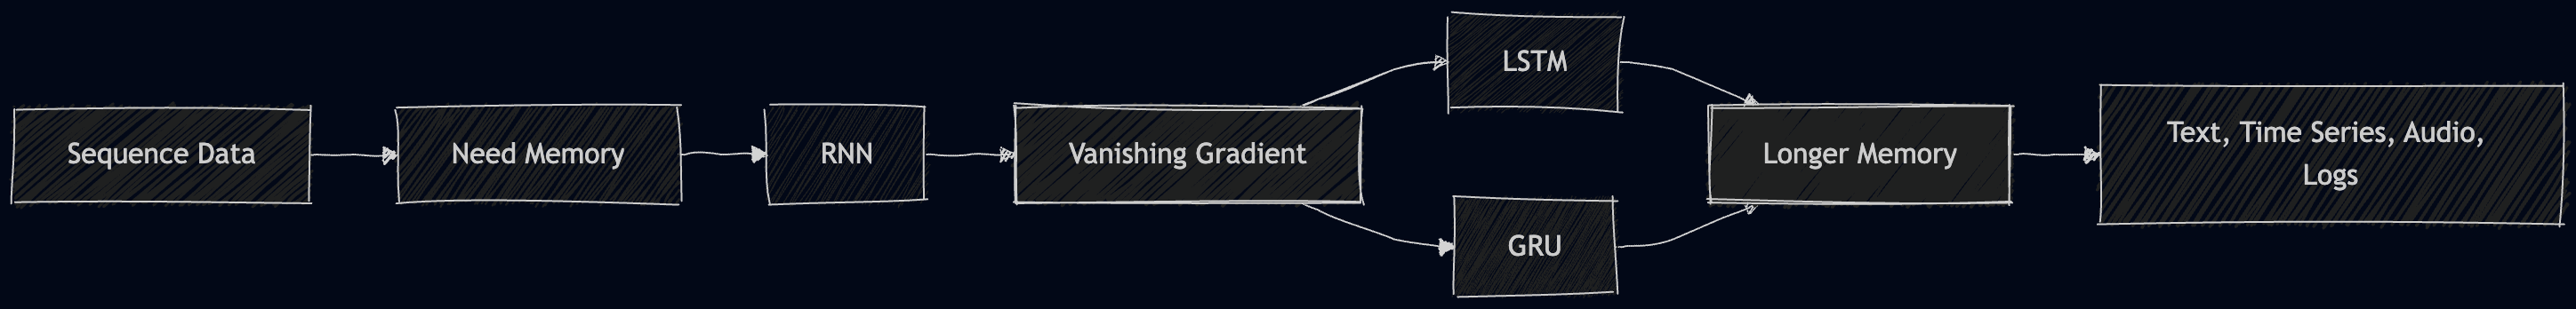

In [ ]:

# - Displays a high-level sequence modeling architecture diagram.

# - Understanding the shared pipeline first makes comparing model variants easier.
# Note:
# - RNN, LSTM, and GRU differ mainly in how they update memory over time.

display(Image(filename="seq_modeling_flow.png", width=950))

## 9. How RNN, LSTM, and GRU differ

| Model | Main memory idea | Main advantage | Main limitation |
| --- | --- | --- | --- |
| RNN | One hidden state passed forward | Easiest to understand and visualize | Can forget long-range context |
| LSTM | Hidden state plus cell state with gates | Better at keeping important long-term information | More parameters and more complexity |
| GRU | Gated hidden state with a simpler design than LSTM | Often strong while staying lighter than LSTM | Still more complex than a plain RNN |

A good way to build intuition:

- Start with RNN as the simple baseline
- Show why memory problems appear
- Introduce LSTM and GRU as gated fixes

## 10. Diagram: vanilla RNN

The vanilla RNN is the simplest recurrent model. Its core update rule is:

> **h_t = tanh( W_hh · h_{t-1} + W_xh · x_t + b )**

In plain language:
- `x_t` — the embedding for the current token
- `h_{t-1}` — the hidden state from the previous step (the model's memory so far)
- `W_hh`, `W_xh`, `b` — learned weight matrices and a bias
- `tanh(...)` — a non-linear activation that squashes values into the range (-1, 1)
- `h_t` — the new hidden state, which becomes the input for the next step

The hidden state is updated at every single token. At the end of the sequence, `h_T` (the final hidden state) is used to make the prediction.

**The vanishing gradient problem**

For long sequences, gradients must be multiplied together across many time steps during backpropagation. The repeated multiplication by the same weight matrix and the `tanh` squashing cause the gradient signal to shrink exponentially as it travels backwards through time. By the time it reaches the early tokens, the gradient is nearly zero — the model effectively "forgets" the beginning of the sentence.

**Why we still start with RNN**

On our dataset, sentences are only 8–11 words long. The vanishing gradient is not severe at this length, so the RNN can still work reasonably well. This makes it the perfect simple baseline: it is easy to understand, and its limitation at longer sequences provides a natural motivation to introduce LSTM and GRU.

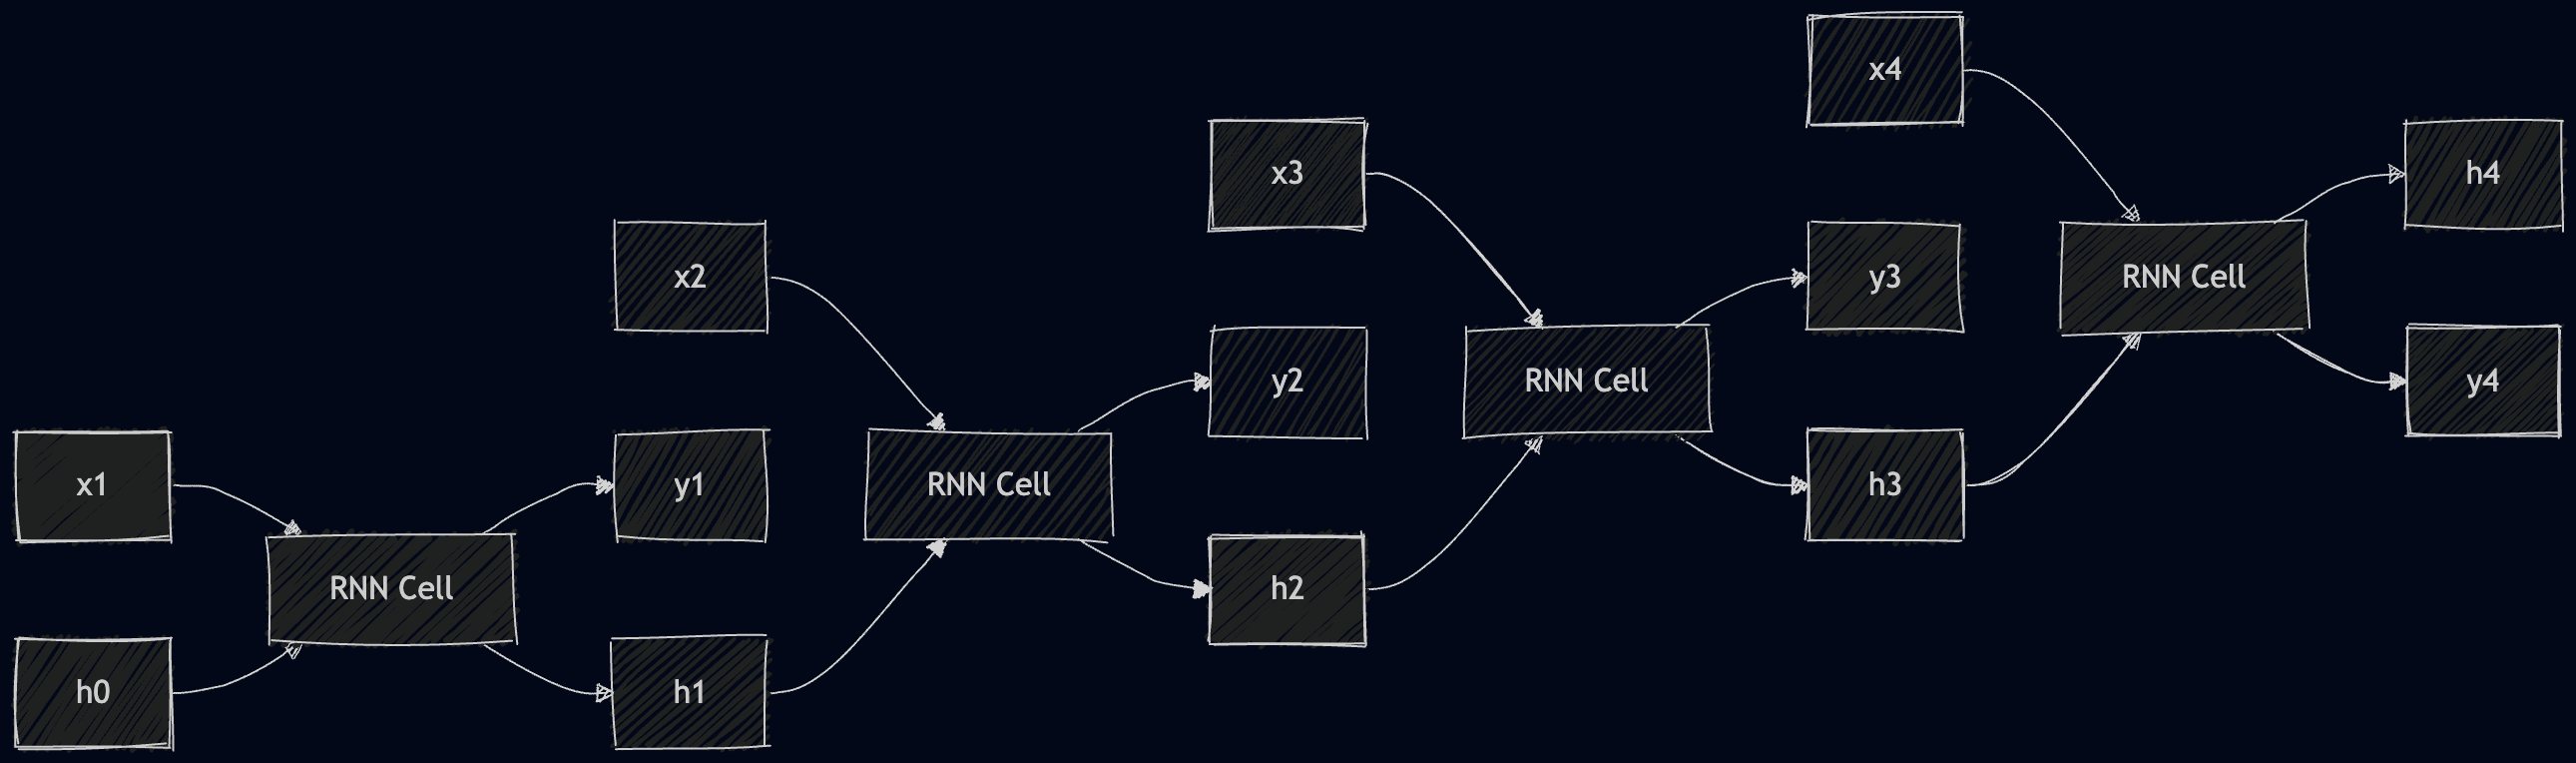

In [ ]:

# - Displays the RNN architecture image.

# - A picture helps connect the formula and the data flow.
# Note:
# - The hidden state is the RNN's memory.

display(Image(filename="rnn.png", width=850))

## 11. Diagram: LSTM

LSTM (Long Short-Term Memory) was introduced specifically to solve the vanishing gradient problem. It does this by adding two innovations:

**Innovation 1 — A second memory pathway: the cell state**
The cell state `c_t` runs alongside the hidden state `h_t`. It is designed to carry long-range information with very little modification at each step — like a conveyor belt passing information across many time steps.

**Innovation 2 — Three gates**
Gates are sigmoid-activated vectors (values between 0 and 1) that control how much information flows. You can think of a gate value near 1 as "let this through" and near 0 as "block this."

| Gate | Question it answers |
|------|---------------------|
| **Forget gate** `f_t` | How much of the old cell state should we *erase*? |
| **Input gate** `i_t` | How much new information should we *write* into the cell state? |
| **Output gate** `o_t` | How much of the cell state should we *expose* as the hidden state? |

**A concrete example:**

Imagine processing the sentence `"The movie was not good"`. When the LSTM reads `"not"`, the forget gate can choose to erase positive signals that were built up from words like `"movie"`, and the input gate can write a new, negative signal. The cell state carries this negative signal forward through `"good"` so that the final hidden state reflects the negation rather than the surface-level positive word.

**The key advantage**

Because the cell state is updated *additively* (not multiplicatively at every step), gradients can flow backwards through time without shrinking to zero. This allows LSTMs to learn dependencies over sequences much longer than a vanilla RNN can handle.

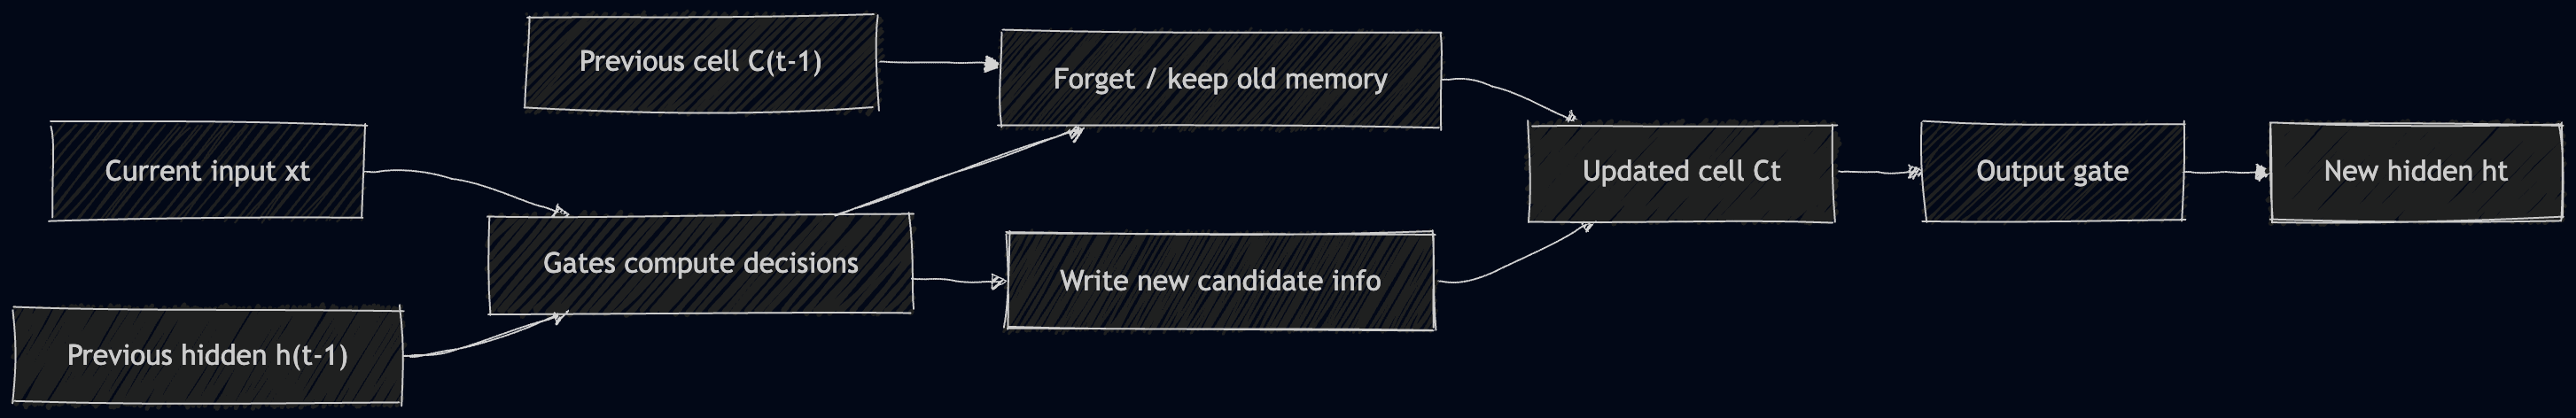

In [ ]:

# - Displays the LSTM architecture image.

# - LSTM is easier to understand after seeing the gates visually.
# Note:
# - The cell state is the long-term memory path.

display(Image(filename="lstm.png", width=850))

## 12. Diagram: GRU

GRU (Gated Recurrent Unit) was introduced as a streamlined alternative to LSTM. The key design decision: **eliminate the separate cell state** and achieve gated memory using only the hidden state.

**The two GRU gates:**

| Gate | What it does |
|------|--------------|
| **Update gate** `z_t` | Decides how much of the *old* hidden state to keep versus how much to replace with new information. A value near 1 means "keep the old memory"; near 0 means "write new information". |
| **Reset gate** `r_t` | Decides how much of the *old* hidden state to use when computing the candidate new hidden state. A value near 0 means "ignore previous memory when writing the candidate". |

**How it compares to LSTM:**

| | LSTM | GRU |
|--|------|-----|
| Memory pathways | 2 (hidden state + cell state) | 1 (hidden state only) |
| Number of gates | 3 (forget, input, output) | 2 (update, reset) |
| Parameters | More | Fewer |
| Typical performance | Strong on long sequences | Competitive with LSTM, faster to train |

**The key intuition**

The update gate in GRU plays a combined role similar to both the forget gate and input gate in LSTM — it decides in one step how much to forget and how much to add. This simplification works well in practice on many tasks, especially when sequences are not extremely long.

The diagram below (drawn with `matplotlib`) shows the conceptual flow of a GRU cell.

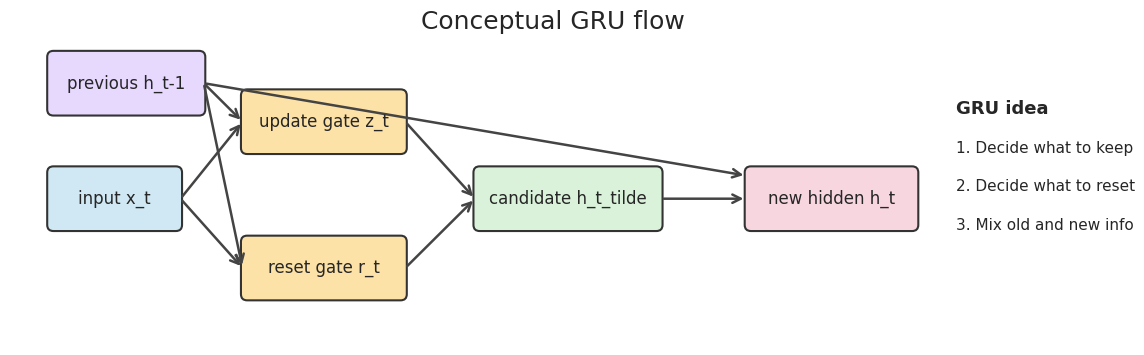

In [ ]:

# - Draws a simple conceptual GRU diagram with matplotlib.

# - We do not have a saved GRU image in this folder, so we draw a simple sketch.
# Note:
# - This is a conceptual diagram, not the exact computational graph used by PyTorch.

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")


def add_box(x, y, w, h, label, color):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="#333333",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=12)


def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.8,
        color="#444444",
    )
    ax.add_patch(arrow)


add_box(0.5, 1.5, 1.7, 0.8, "input x_t", "#CFE8F3")
add_box(3.0, 2.5, 2.1, 0.8, "update gate z_t", "#FDE2A7")
add_box(3.0, 0.6, 2.1, 0.8, "reset gate r_t", "#FDE2A7")
add_box(6.0, 1.5, 2.4, 0.8, "candidate h_t_tilde", "#D9F2D9")
add_box(9.5, 1.5, 2.2, 0.8, "new hidden h_t", "#F7D6E0")
add_box(0.5, 3.0, 2.0, 0.8, "previous h_t-1", "#E7D8FD")

add_arrow(2.2, 1.9, 3.0, 2.9)
add_arrow(2.2, 1.9, 3.0, 1.0)
add_arrow(2.5, 3.4, 3.0, 2.9)
add_arrow(2.5, 3.4, 3.0, 1.0)
add_arrow(5.1, 2.9, 6.0, 1.9)
add_arrow(5.1, 1.0, 6.0, 1.9)
add_arrow(8.4, 1.9, 9.5, 1.9)
add_arrow(2.5, 3.4, 9.5, 2.2)

ax.text(12.2, 3.0, "GRU idea", fontsize=13, fontweight="bold")
ax.text(12.2, 2.5, "1. Decide what to keep", fontsize=11)
ax.text(12.2, 2.0, "2. Decide what to reset", fontsize=11)
ax.text(12.2, 1.5, "3. Mix old and new info", fontsize=11)

plt.title("Conceptual GRU flow")
plt.show()

## 13. Define One Reusable PyTorch Classifier

Rather than writing three separate model classes, we write one `SequenceClassifier` that accepts a `model_type` string (`"RNN"`, `"LSTM"`, or `"GRU"`) and swaps the recurrent layer accordingly. This is the key insight: **the overall architecture is shared; only the memory mechanism changes.**

**The four layers of the classifier:**

```
Input IDs  →  Embedding  →  RNN / LSTM / GRU  →  Dropout  →  Linear  →  Logit
```

1. **`nn.Embedding`** — Converts integer token IDs into dense float vectors. The `padding_idx=0` argument tells PyTorch that ID 0 (`<PAD>`) should always map to a zero vector and its gradient should not be updated.

2. **`nn.RNN` / `nn.LSTM` / `nn.GRU`** — The recurrent layer. All three accept the same inputs (packed embeddings) and return the same format (final hidden state), so swapping them requires changing a single string.

3. **`nn.Dropout(0.2)`** — Randomly zeros 20% of the hidden state values during training. Disabled automatically during `model.eval()`.

4. **`nn.Linear(hidden_dim, 1)`** — Maps the 48-dimensional hidden vector to a single number (the logit). Positive logit → "positive" sentiment; negative logit → "negative" sentiment.

**Two important helper details:**

- **`pack_padded_sequence`** — Before passing embeddings to the recurrent layer, we pack them using the real sequence lengths. This tells the layer to skip padding tokens entirely, so they have no effect on the hidden state.

- **Gradient clipping (`max_norm=1.0`)** — During training, we clip gradients whose norm exceeds 1.0. This prevents the exploding gradient problem, where a single large gradient update destabilises all the learned weights.

**Training strategy — save the best checkpoint**

We track the validation loss after every epoch. Whenever it improves, we save a copy of the model weights. At the very end, we load those best weights before evaluating on the test set. This is called *early stopping by checkpoint* and prevents us from using an overfit model for final evaluation.

In [ ]:

# - Defines a reusable sequence classifier.
# - Adds helper functions for training, validation, testing, plotting, and prediction.

# - A common training pipeline makes the model comparison fair.
# Note:
# - We use pack_padded_sequence so padded zeros do not behave like real words.

class SequenceClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        pad_idx: int,
        model_type: str = "RNN",
        dropout: float = 0.2,
    ):
        super().__init__()
        self.model_type = model_type.upper()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        if self.model_type == "RNN":
            self.sequence_layer = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )
        elif self.model_type == "LSTM":
            self.sequence_layer = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )
        elif self.model_type == "GRU":
            self.sequence_layer = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )
        else:
            raise ValueError("model_type must be one of: RNN, LSTM, GRU")

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, text_batch, lengths):
        embedded = self.embedding(text_batch)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        if self.model_type == "LSTM":
            _, (hidden, cell_state) = self.sequence_layer(packed)
        else:
            _, hidden = self.sequence_layer(packed)

        last_hidden = hidden[-1]
        logits = self.classifier(self.dropout(last_hidden)).squeeze(1)
        return logits


def batch_accuracy(logits, labels):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    return (predictions == labels).float().mean().item()


def run_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for text_batch, lengths, labels in data_loader:
        text_batch = text_batch.to(DEVICE)
        lengths = lengths.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(text_batch, lengths)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item()

        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().astype(int).tolist())
        all_probabilities.extend(probabilities.detach().cpu().numpy().tolist())

    epoch_accuracy = float(
        np.mean(np.array(all_predictions) == np.array(all_labels))
    )

    return {
        "loss": total_loss / len(data_loader),
        "accuracy": epoch_accuracy,
        "labels": all_labels,
        "predictions": all_predictions,
        "probabilities": all_probabilities,
    }


def run_experiment(model_type: str, epochs: int = 10, learning_rate: float = 0.003):
    model = SequenceClassifier(
        vocab_size=len(word_to_idx),
        embedding_dim=32,
        hidden_dim=48,
        pad_idx=PAD_IDX,
        model_type=model_type,
        dropout=0.2,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")

    print(f"Training {model_type} model")
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d} | "
            f"train loss: {train_metrics['loss']:.4f} | "
            f"train acc: {train_metrics['accuracy']:.3f} | "
            f"val loss: {val_metrics['loss']:.4f} | "
            f"val acc: {val_metrics['accuracy']:.3f}"
        )

    model.load_state_dict(best_state)
    test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)
    report = classification_report(
        test_metrics["labels"],
        test_metrics["predictions"],
        target_names=["negative", "positive"],
        output_dict=True,
        zero_division=0,
    )

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "report": report,
        "confusion_matrix": confusion_matrix(
            test_metrics["labels"], test_metrics["predictions"]
        ),
    }


def display_results(model_name: str, result: dict):
    print(f"{model_name} test loss: {result['test_metrics']['loss']:.4f}")
    print(f"{model_name} test accuracy: {result['test_metrics']['accuracy']:.3f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        ax=ax,
    )
    ax.set_title(f"{model_name} confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()

    report_df = pd.DataFrame(result["report"]).T.round(3)
    display(report_df)


def predict_text(model, text: str):
    model.eval()
    cleaned = clean_text(text)
    tokens = tokenize(cleaned)
    token_ids = encode_tokens(tokens, word_to_idx)
    effective_length = min(len(token_ids), max_length)
    padded_ids = pad_sequence(token_ids, max_length, PAD_IDX)

    text_tensor = torch.tensor([padded_ids], dtype=torch.long).to(DEVICE)
    length_tensor = torch.tensor([effective_length], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logit = model(text_tensor, length_tensor)
        probability = torch.sigmoid(logit).item()

    label = "positive" if probability >= 0.5 else "negative"
    return label, probability


results = {}

## 14. Train the Vanilla RNN Baseline

This cell trains our first model using the simplest recurrent architecture. We always start here for two reasons:
1. The RNN is the easiest to explain conceptually — there is only one hidden state and one update equation.
2. Its results give us a **baseline** that tells us whether LSTM and GRU are actually improving things.

**What to watch in the training log:**

Each line shows four numbers:
- **train loss** — how much the model is wrong on training data (lower is better)
- **train acc** — fraction of training examples classified correctly
- **val loss** — how much the model is wrong on unseen validation data
- **val acc** — fraction of validation examples classified correctly

**Healthy training looks like this:**
- Both train and val loss decrease over epochs.
- Both train and val accuracy increase over epochs.
- The gap between train and val accuracy grows slowly but does not explode.

**Warning signs:**
- If train loss keeps dropping but val loss stops decreasing or starts rising, the model is **overfitting** — it is memorising the training data rather than learning general patterns.
- If train loss barely moves, the learning rate may be too low or the model may be too simple.

**What to expect here:**
On this 100-example dataset, the RNN should reach around 85–90% validation accuracy by epoch 10. Do not over-interpret exact numbers — with a dataset this small, a single misclassified example shifts accuracy by ~4.5%.

In [ ]:

# - Trains the vanilla RNN model.

# - RNN gives us a simple baseline before introducing gated models.
# Note:
# - If the RNN struggles on longer dependencies, that becomes a natural motivation for LSTM and GRU.

results["RNN"] = run_experiment("RNN", epochs=10, learning_rate=0.003)

Training RNN model
Epoch 01 | train loss: 0.7301 | train acc: 0.450 | val loss: 0.6939 | val acc: 0.545
Epoch 02 | train loss: 0.6610 | train acc: 0.670 | val loss: 0.6651 | val acc: 0.591
Epoch 03 | train loss: 0.6063 | train acc: 0.790 | val loss: 0.5692 | val acc: 0.818
Epoch 04 | train loss: 0.4138 | train acc: 0.960 | val loss: 0.4641 | val acc: 0.818
Epoch 05 | train loss: 0.2443 | train acc: 0.930 | val loss: 0.3703 | val acc: 0.818
Epoch 06 | train loss: 0.1495 | train acc: 0.950 | val loss: 0.2940 | val acc: 0.864
Epoch 07 | train loss: 0.1039 | train acc: 0.960 | val loss: 0.2248 | val acc: 0.864
Epoch 08 | train loss: 0.0546 | train acc: 0.990 | val loss: 0.2078 | val acc: 0.864
Epoch 09 | train loss: 0.0398 | train acc: 0.990 | val loss: 0.1955 | val acc: 0.909
Epoch 10 | train loss: 0.0276 | train acc: 1.000 | val loss: 0.1674 | val acc: 0.864


RNN test loss: 0.2225
RNN test accuracy: 0.864


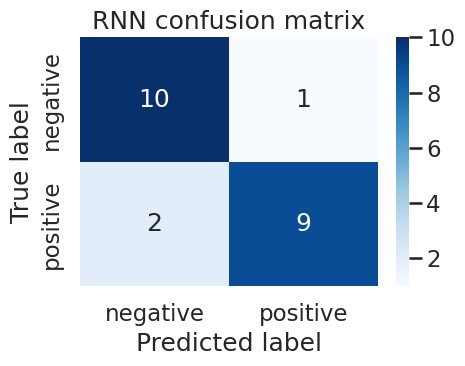

,precision,recall,f1-score,support
negative,0.833,0.909,0.870,11.000
positive,0.900,0.818,0.857,11.000
accuracy,0.864,0.864,0.864,0.864
macro avg,0.867,0.864,0.863,22.000
weighted avg,0.867,0.864,0.863,22.000


In [ ]:

# - Displays the RNN confusion matrix and classification report.

# - Accuracy alone is not enough; class-wise performance matters too.
# Note:
# - A confusion matrix is especially easy to explain on the board.

display_results("RNN", results["RNN"])

## 15. Train the LSTM Model

We now swap the recurrent layer from `nn.RNN` to `nn.LSTM`. Everything else — the dataset, the vocabulary, the embeddings, the training loop, the hyperparameters — stays exactly the same. This is intentional: **we isolate the memory mechanism as the only variable**.

**What changes inside the model:**

The LSTM maintains two vectors at each time step instead of one:
- `h_t` — the hidden state (same role as in the vanilla RNN)
- `c_t` — the cell state (the new long-term memory lane)

The three gates (forget, input, output) allow the model to selectively write to and read from the cell state. This makes the LSTM's gradient flow more stable, especially for longer sequences.

**What typically changes in training behaviour:**

- You may see the LSTM converge more **smoothly** than the RNN — fewer sharp jumps in validation accuracy between epochs.
- On short sequences like ours, the gap between RNN and LSTM performance is often small. The real advantage of LSTM shows on sequences of 50+ tokens.
- The LSTM has roughly **4× more parameters** inside the recurrent layer than the RNN (one matrix per gate), so it takes slightly longer per epoch.

**Focus question:**

Look at the epoch where the validation accuracy first reaches its peak. Did the LSTM get there in fewer epochs than the RNN, or more? What does that tell you about the trade-off between model complexity and convergence speed?

In [ ]:

# - Trains the LSTM model with the same pipeline and hyperparameters.

# - This makes the comparison with RNN fair and easy to explain.
# Note:
# - Any performance gain now comes mostly from better memory handling.

results["LSTM"] = run_experiment("LSTM", epochs=10, learning_rate=0.003)

Training LSTM model
Epoch 01 | train loss: 0.7021 | train acc: 0.390 | val loss: 0.6979 | val acc: 0.545
Epoch 02 | train loss: 0.6814 | train acc: 0.550 | val loss: 0.6888 | val acc: 0.545
Epoch 03 | train loss: 0.6581 | train acc: 0.770 | val loss: 0.6628 | val acc: 0.773
Epoch 04 | train loss: 0.5860 | train acc: 0.890 | val loss: 0.5836 | val acc: 0.818
Epoch 05 | train loss: 0.4677 | train acc: 0.860 | val loss: 0.4730 | val acc: 0.773
Epoch 06 | train loss: 0.2315 | train acc: 0.960 | val loss: 0.4559 | val acc: 0.818
Epoch 07 | train loss: 0.1262 | train acc: 0.940 | val loss: 0.4590 | val acc: 0.818
Epoch 08 | train loss: 0.0846 | train acc: 0.960 | val loss: 0.3558 | val acc: 0.773
Epoch 09 | train loss: 0.0595 | train acc: 0.970 | val loss: 0.2742 | val acc: 0.864
Epoch 10 | train loss: 0.0537 | train acc: 0.990 | val loss: 0.2396 | val acc: 0.864


LSTM test loss: 0.1682
LSTM test accuracy: 0.818


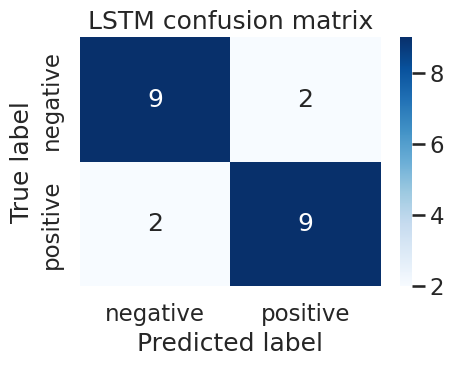

,precision,recall,f1-score,support
negative,0.818,0.818,0.818,11.000
positive,0.818,0.818,0.818,11.000
accuracy,0.818,0.818,0.818,0.818
macro avg,0.818,0.818,0.818,22.000
weighted avg,0.818,0.818,0.818,22.000


In [ ]:

# - Displays the LSTM confusion matrix and classification report.

# - Compare the same metrics seen for the RNN.
# Note:
# - If LSTM performs better, connect that improvement to gated memory.

display_results("LSTM", results["LSTM"])

## 16. Train the GRU Model

The third and final model swaps the recurrent layer to `nn.GRU`. As before, every other part of the experiment is identical.

**What changes inside the model:**

GRU also uses gates, but it eliminates the separate cell state. Instead, a single update gate decides how much of the old hidden state to keep versus how much to replace. This gives GRU fewer parameters than LSTM, which means:
- **Faster training** — fewer multiplications per step
- **Potentially better generalisation on small datasets** — fewer parameters means less risk of overfitting

**Three-way comparison scaffold:**

By the time you have all three training logs, you can ask:

| Question | What to look for |
|----------|-----------------|
| Which model converged fastest? | Which reached high val accuracy in fewest epochs? |
| Which was most stable? | Which had the smallest epoch-to-epoch variation in val accuracy? |
| Which performed best on the test set? | Wait for Section 17 |
| Was the more complex model worth it? | Compare LSTM vs GRU — is the gap meaningful? |

**Expected result on this dataset:**

On a 100-example dataset, GRU typically performs comparably to LSTM. The difference is often within the noise of a single misclassified example. This is an important lesson: **model complexity should be justified by dataset size and task difficulty, not assumed to always help.**

In [ ]:

# - Trains the GRU model with the same experimental setup.

# - Using the same dataset and training loop makes the comparison meaningful.
# Note:
# - GRU is often a good compromise between RNN simplicity and LSTM memory power.

results["GRU"] = run_experiment("GRU", epochs=10, learning_rate=0.003)

Training GRU model
Epoch 01 | train loss: 0.6964 | train acc: 0.470 | val loss: 0.6615 | val acc: 0.682
Epoch 02 | train loss: 0.6706 | train acc: 0.670 | val loss: 0.6418 | val acc: 0.773
Epoch 03 | train loss: 0.6219 | train acc: 0.800 | val loss: 0.5775 | val acc: 0.864
Epoch 04 | train loss: 0.4765 | train acc: 0.930 | val loss: 0.4348 | val acc: 0.818
Epoch 05 | train loss: 0.2853 | train acc: 0.910 | val loss: 0.3575 | val acc: 0.864
Epoch 06 | train loss: 0.2050 | train acc: 0.910 | val loss: 0.3658 | val acc: 0.818
Epoch 07 | train loss: 0.1135 | train acc: 0.960 | val loss: 0.3538 | val acc: 0.773
Epoch 08 | train loss: 0.0690 | train acc: 0.960 | val loss: 0.3524 | val acc: 0.773
Epoch 09 | train loss: 0.0378 | train acc: 1.000 | val loss: 0.3594 | val acc: 0.773
Epoch 10 | train loss: 0.0267 | train acc: 1.000 | val loss: 0.3875 | val acc: 0.773


GRU test loss: 0.1592
GRU test accuracy: 0.818


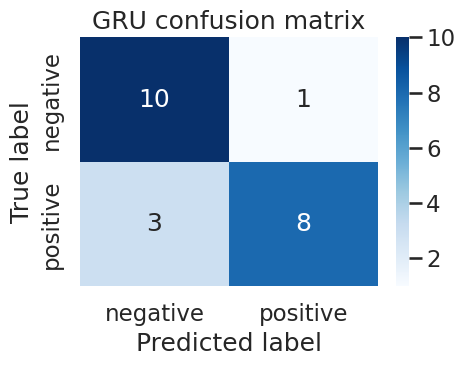

,precision,recall,f1-score,support
negative,0.769,0.909,0.833,11.000
positive,0.889,0.727,0.800,11.000
accuracy,0.818,0.818,0.818,0.818
macro avg,0.829,0.818,0.817,22.000
weighted avg,0.829,0.818,0.817,22.000


In [ ]:

# - Displays the GRU confusion matrix and classification report.

# - Compare all three models using the same view.
# Note:
# - The best model on this tiny dataset may vary a little across runs, even with fixed seeds.

display_results("GRU", results["GRU"])

## 17. Compare All Three Models

This section brings everything together into a side-by-side comparison. We look at three metrics:

| Metric | What it measures |
|--------|-----------------|
| **Test accuracy** | Overall fraction of test examples classified correctly |
| **Positive F1** | The harmonic mean of precision and recall *for the positive class specifically* |
| **Macro F1** | The average F1 score across both classes, treating them equally |

**Why use F1 and not just accuracy?**

On balanced datasets (equal number of positives and negatives), accuracy and macro F1 tell a similar story. But on imbalanced datasets, a model could achieve high accuracy by always predicting the majority class while completely failing on the minority class. F1 penalises this behaviour.

**How to read the validation accuracy curves:**

The left plot shows how each model's validation accuracy evolved across 10 epochs. Healthy curves rise then plateau. A curve that oscillates widely means the model is unstable — possibly the learning rate is too high or the dataset is too small for reliable estimates.

**How to read the bar chart:**

The right bar chart shows the final test accuracy for each model. On a dataset of only 22 test examples, each bar is subject to high variance — a single misclassification moves the bar by ~4.5%.

**Discussion questions:**

1. Which model has the highest test accuracy? Is that the model you expected to win?
2. Are the differences statistically meaningful given the tiny test set size?
3. If you had to deploy one of these models for production, which would you choose and why? (Hint: accuracy is not the only criterion — consider speed, interpretability, and robustness.)
4. What would you change in the training setup to make this comparison more reliable?

,model,test_accuracy,positive_f1,macro_f1
0,RNN,0.864,0.857,0.863
1,LSTM,0.818,0.818,0.818
2,GRU,0.818,0.800,0.817


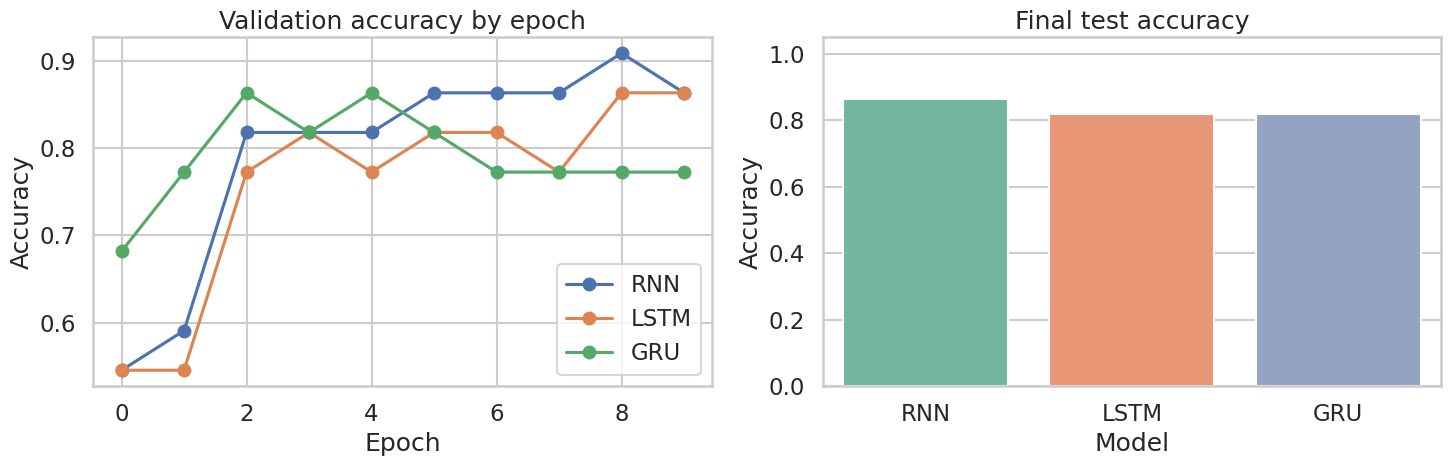

In [ ]:

# - Builds a summary table for RNN, LSTM, and GRU.
# - Plots validation accuracy curves and final test accuracy bars.

# - Side-by-side comparison is the easiest way to teach model trade-offs.
# Note:
# - On small clean datasets, all three models can perform well.

summary_rows = []
for model_name, result in results.items():
    summary_rows.append(
        {
            "model": model_name,
            "test_accuracy": round(result["test_metrics"]["accuracy"], 3),
            "positive_f1": round(result["report"]["positive"]["f1-score"], 3),
            "macro_f1": round(result["report"]["macro avg"]["f1-score"], 3),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(
    by="test_accuracy", ascending=False
)
display(summary_df.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for model_name, result in results.items():
    axes[0].plot(
        result["history"]["val_accuracy"],
        marker="o",
        label=model_name,
    )
axes[0].set_title("Validation accuracy by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

sns.barplot(
    data=summary_df,
    x="model",
    y="test_accuracy",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Final test accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 18. Try a Few Custom Sentences

This is the most intuitive part of the notebook. We take sentences that were never in the training or test sets and ask each model to classify them in real time.

**How to read the output:**

Each row shows:
- The input sentence
- The predicted label (`positive` or `negative`) from each model
- The **positive probability** — the model's confidence that the sentence is positive

| Probability | Interpretation |
|-------------|---------------|
| Close to 1.0 | Model is very confident this is positive |
| Close to 0.5 | Model is uncertain (near the decision boundary) |
| Close to 0.0 | Model is very confident this is negative |

**Try modifying the sentences yourself:**

Add your own sentences to `demo_sentences` and re-run the cell. Experiment with:
- Negations: does the model correctly handle `"not good"` vs `"not bad"`?
- Mixed sentiment: `"the content was great but the app kept crashing"` — what does the model do?
- Unknown words: use a word that is not in the training vocabulary (it maps to `<UNK>`) — does the model still make a reasonable guess?
- Short vs long sentences: does length affect confidence?

**What this teaches:**

Real-world model evaluation always includes a qualitative "does it feel right?" step alongside quantitative metrics. Looking at specific predictions helps you catch systematic failures — such as a model that ignores negation — that aggregate accuracy scores can hide.

In [ ]:

# - Runs a few custom sentences through all trained models.

# - This cell connects the abstract model output back to real language.
# Note:
# - The probability is the model's confidence for the positive class.

demo_sentences = [
    "the app was smooth, reliable, and easy to use",
    "the website was slow and confusing during the demo",
    "the lesson was clear, simple, and helpful for new users",
    "the platform was messy, unclear, and frustrating",
]

prediction_rows = []
for sentence in demo_sentences:
    row = {"sentence": sentence}
    for model_name, result in results.items():
        label, probability = predict_text(result["model"], sentence)
        row[f"{model_name} label"] = label
        row[f"{model_name} positive_prob"] = round(probability, 3)
    prediction_rows.append(row)

display(pd.DataFrame(prediction_rows))

,sentence,RNN label,RNN positive_prob,LSTM label,LSTM positive_prob,GRU label,GRU positive_prob
0,"the app was smooth, reliable, and easy to use",positive,0.989,positive,0.930,positive,0.978
1,the website was slow and confusing during the ...,negative,0.043,negative,0.010,negative,0.148
2,"the lesson was clear, simple, and helpful for ...",positive,0.979,positive,0.993,positive,0.836
3,"the platform was messy, unclear, and frustrating",negative,0.036,negative,0.067,negative,0.237
